
# Support Vector Machines for Bioinformatics Classification
## Fully Worked Notebook and Solution Key

This notebook provides a complete worked solution for the SVM homework assignment in **Applied Data Mining for Bioinformatics**.

Because no dataset was uploaded with the assignment, this notebook first **generates a synthetic gene-expression-style dataset** with:
- many features,
- a small set of truly informative genes,
- binary disease labels.

You can replace the synthetic dataset with a real file later by swapping the data-loading cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(7)

# Part I — Conceptual Foundations (Solution Key)

## Question 1 — Hyperplane and margin

A linear SVM decision boundary is:

$$
w^T x + b = 0
$$

### 1. What is a hyperplane in high-dimensional gene expression space?
A hyperplane is a flat decision boundary in feature space. If there are \(p\) genes, each sample is a point in \(p\)-dimensional space, and the hyperplane has dimension \(p-1\).

### 2. What is the margin?
The margin is the perpendicular distance between the decision boundary and the closest training points from either class. SVM chooses the boundary with the largest possible margin.

### 3. Why is the distance to $w^T x + b = 1$ equal to $1/\|w\|$?
The distance from a point $x$ to the hyperplane $(w^T x + b = 0)$ is:

$$
\frac{|w^T x + b|}{\|w\|}
$$

For a point on the upper margin boundary, $w^T x + b = 1$, so the distance is:

$$
\frac{|1|}{\|w\|} = \frac{1}{\|w\|}
$$

Maximizing this distance improves generalization because it makes the classifier more robust to small perturbations and noise.


## Question 2 — Hinge loss and slack variables

Hinge loss is:

$$
L(y_i, z_i) = \max(0, 1 - y_i z_i)
$$

We compute the four losses below.

In [ ]:

examples = pd.DataFrame({
    "Sample": [1, 2, 3, 4],
    "y": [1, 1, -1, -1],
    "z": [2.5, 0.7, -0.2, 1.0]
})

examples["y*z"] = examples["y"] * examples["z"]
examples["hinge_loss"] = np.maximum(0, 1 - examples["y*z"])

def classify_case(z):
    if z >= 1:
        return "correctly classified outside margin"
    elif z > 0:
        return "correctly classified inside margin"
    else:
        return "misclassified"

examples["interpretation"] = examples["y*z"].apply(classify_case)
examples


Slack variables are equivalent to hinge losses for soft-margin SVM:
$$
\xi_i = \max(0, 1 - y_i z_i)
$$

## Question 3 — Support vectors

1. **Support vectors** are the training samples closest to the decision boundary; they determine the position of the margin and the hyperplane.
2. Removing a **non-support-vector** sample usually does not change the model because those points lie safely away from the boundary and have zero influence in the dual solution.
3. In bioinformatics, support vectors may correspond to **borderline or heterogeneous samples**, such as atypical disease cases, noisy measurements, or biologically mixed phenotypes.


# Part II — Linear SVM on a Gene Expression Dataset

We generate a synthetic gene-expression-style dataset with:
- 180 patients
- 300 genes
- 20 informative genes
- binary disease label

This gives a realistic *p >> n* flavor, while still being small enough for a classroom notebook.


In [ ]:

X, y = make_classification(
    n_samples=180,
    n_features=300,
    n_informative=20,
    n_redundant=10,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.03,
    random_state=7
)

feature_names = [f"Gene_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["disease_label"] = y
df.head()


In [ ]:

csv_path = "gene_expression_binary.csv"
df.to_csv(csv_path, index=False)
print(f"Saved synthetic dataset to {csv_path}")
print(df.shape)


In [5]:
in_file_name = "gene_expression_binary.csv"
df = pd.read_csv(in_file_name)

print(df.head())

     Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6    Gene_7  \
0  0.165362  1.052481  0.250059  0.647174  0.999504  7.399953 -0.139929   
1 -0.780324 -0.108025  0.716442  0.435419 -0.609848 -0.242195 -0.439404   
2  0.231719 -1.680229 -0.565501 -0.042879 -0.494839  4.032141  0.764033   
3  0.491246  0.388259 -1.901445  1.927810  0.204609  4.682180  0.168620   
4 -2.448968  2.164372 -0.509130 -0.013008  1.309486 -2.768720 -0.479120   

     Gene_8    Gene_9   Gene_10  ...  Gene_292  Gene_293   Gene_294  Gene_295  \
0 -0.825100 -1.731810  0.490245  ...  1.835600  1.515755  -0.091484 -0.932527   
1  0.193077  2.019842  1.014541  ...  1.146299  0.978062 -12.977023 -0.012661   
2 -1.069174  0.868155  1.517235  ...  0.307717 -1.219386  17.469884 -1.112189   
3 -0.259217 -0.272536 -0.005169  ...  0.628027  0.454545  -6.172395 -1.510199   
4  0.468360 -1.277465 -0.972258  ...  1.002873 -0.736546  -0.641376  0.128546   

   Gene_296  Gene_297  Gene_298  Gene_299  Gene_300  disease_l


## Task 1 — Data preprocessing

We split the data into training and test sets, then standardize the features.

### Why scaling is necessary for SVM
SVM relies on distances and dot products. If one gene has a much larger numeric scale than another, it can dominate the optimization. Standardization makes each feature comparable by putting them on a similar scale.


In [8]:
X = df.drop(columns=["disease_label"]).values
feature_names = df.drop(columns=["disease_label"]).columns.tolist()

y = df["disease_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=7
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training shape: (126, 300)
Test shape: (54, 300)
Training class counts: [63 63]
Test class counts: [27 27]



## Task 2 — Train linear SVM


In [9]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

linear_pipeline.fit(X_train, y_train)

y_train_pred = linear_pipeline.predict(X_train)
y_test_pred = linear_pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

svm_linear = linear_pipeline.named_steps["svm"]

print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))
print("Number of support vectors:", len(svm_linear.support_))
print("Support vectors per class:", svm_linear.n_support_)

Training accuracy: 1.0
Test accuracy: 0.8148
Number of support vectors: 107
Support vectors per class: [54 53]



### Interpretation
- A **high training accuracy** and somewhat lower **test accuracy** can suggest mild overfitting.
- A **large fraction of support vectors** suggests the classes are overlapping, noisy, or difficult to separate.
- A **small fraction of support vectors** suggests a cleaner separation.



## Task 3 — Feature importance interpretation

For a **linear** SVM, the coefficients define the separating hyperplane. Features with large absolute coefficients contribute more strongly to the decision function.

Because we standardized the features, the coefficients are comparable across genes.


In [10]:
coef = svm_linear.coef_[0]
coef_series = pd.Series(coef, index=feature_names)

top15 = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(15)
top15_df = pd.DataFrame({
    "gene": top15.index,
    "coefficient": top15.values,
    "abs_coefficient": np.abs(top15.values)
})
top15_df


,gene,coefficient,abs_coefficient
0,Gene_69,0.132147,0.132147
1,Gene_117,-0.127141,0.127141
2,Gene_134,-0.125200,0.125200
3,Gene_251,-0.113441,0.113441
4,Gene_95,-0.102428,0.102428
5,Gene_14,-0.099478,0.099478
6,Gene_241,0.096610,0.096610
7,Gene_230,-0.090597,0.090597
8,Gene_246,0.090134,0.090134
9,Gene_6,-0.085485,0.085485


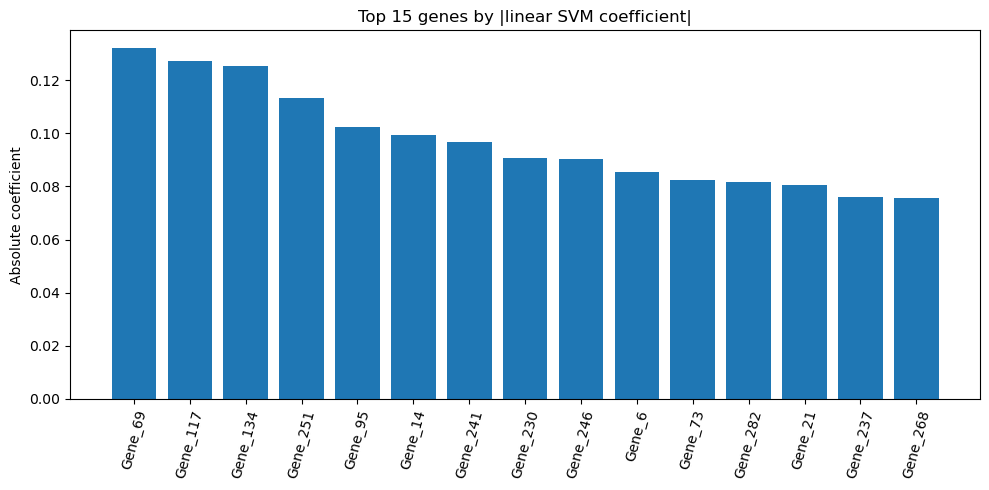

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(top15_df["gene"], top15_df["abs_coefficient"])
plt.xticks(rotation=75)
plt.ylabel("Absolute coefficient")
plt.title("Top 15 genes by |linear SVM coefficient|")
plt.tight_layout()
plt.show()

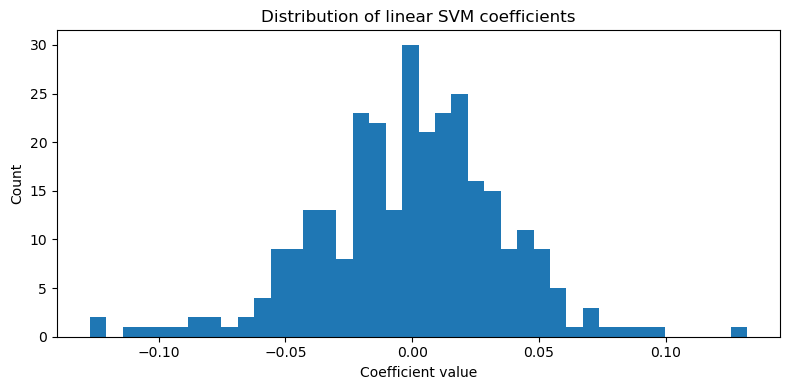

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(coef, bins=40)
plt.xlabel("Coefficient value")
plt.ylabel("Count")
plt.title("Distribution of linear SVM coefficients")
plt.tight_layout()
plt.show()


### Example biological interpretation
The top-ranked genes are candidate biomarkers because their standardized expression values contribute strongly to separating disease from control samples. In a real dataset, these genes would be followed up with pathway analysis, literature review, or differential expression testing.



# Part III — Hyperparameter Tuning (Linear SVM)

We tune \(C\) using **Stratified 5-fold cross-validation**.
- Small \(C\): wider margin, more regularization
- Large \(C\): narrower margin, less regularization, higher risk of overfitting


In [13]:
C_values = [0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

cv_results = []

for C in C_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({
        "C": C,
        "cv_mean_accuracy": scores.mean(),
        "cv_std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df


,C,cv_mean_accuracy,cv_std
0,0.01,0.730769,0.048573
1,0.10,0.746769,0.074824
2,1.00,0.746769,0.074824
3,10.00,0.746769,0.074824
4,100.00,0.746769,0.074824


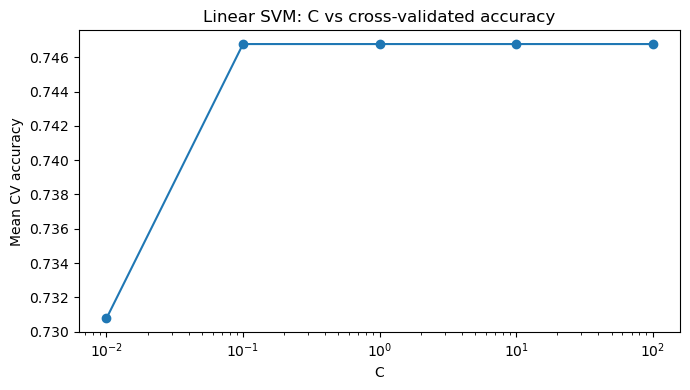

Best C: 0.1


In [14]:
plt.figure(figsize=(7, 4))
plt.semilogx(cv_df["C"], cv_df["cv_mean_accuracy"], marker="o")
plt.xlabel("C")
plt.ylabel("Mean CV accuracy")
plt.title("Linear SVM: C vs cross-validated accuracy")
plt.tight_layout()
plt.show()

best_linear_C = cv_df.loc[cv_df["cv_mean_accuracy"].idxmax(), "C"]
print("Best C:", best_linear_C)



### Interpretation
- **Very small \(C\)** allows more margin violations and may underfit.
- **Very large \(C\)** penalizes violations strongly and may overfit noise.
- The best \(C\) is the one with the highest validation accuracy, not necessarily the largest one.



# Part IV — Nonlinear SVM with RBF Kernel

Now we tune an RBF-kernel SVM using grid search over \(C\) and \(\gamma\).


In [15]:
rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    estimator=rbf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

best_rbf = grid.best_estimator_
rbf_test_pred = best_rbf.predict(X_test)
rbf_test_acc = accuracy_score(y_test, rbf_test_pred)
print("RBF test accuracy:", round(rbf_test_acc, 4))
print("Linear test accuracy:", round(test_acc, 4))


Error processing line 1 of /opt/anaconda3/envs/teach_ml/lib/python3.11/site-packages/distutils-precedence.pth:

Error processing line 1 of /opt/anaconda3/envs/teach_ml/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/opt/anaconda3/envs/teach_ml/lib/python3.11/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
  Traceback (most recent call last):
    File "/opt/anaconda3/envs/teach_ml/lib/python3.11/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Error processing line 1 of /opt/anaconda3/envs/teach_ml/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  

Best parameters: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV accuracy: 0.7151
RBF test accuracy: 0.8519
Linear test accuracy: 0.8148



### Interpretation
An RBF SVM may outperform a linear SVM if the disease and control classes are separated by a nonlinear boundary in gene-expression space. In omics data, interactions and nonlinear patterns are common, so the RBF kernel can sometimes capture structure that a linear model misses.



# Part V — Support Vector Analysis

We inspect the best SVM model and analyze margin-related behavior.


In [ ]:

best_svm = best_rbf.named_steps["svm"]

sv_fraction = len(best_svm.support_) / len(X_train)
print("Support vector fraction:", round(sv_fraction, 4))
print("Number of support vectors:", len(best_svm.support_))
print("Support vectors per class:", best_svm.n_support_)


In [ ]:

decision_scores = best_rbf.decision_function(X_train)

plt.figure(figsize=(8, 4))
plt.hist(decision_scores[y_train == 0], bins=20, alpha=0.7, label="Class 0")
plt.hist(decision_scores[y_train == 1], bins=20, alpha=0.7, label="Class 1")
plt.axvline(0, linestyle="--")
plt.xlabel("Decision score f(x)")
plt.ylabel("Count")
plt.title("Training-set decision scores for best SVM")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Identify samples inside margin using y in {-1, +1}
y_train_pm = np.where(y_train == 1, 1, -1)
margin_values = y_train_pm * decision_scores
inside_margin_idx = np.where(margin_values < 1)[0]

print("Number of training samples with y*f(x) < 1:", len(inside_margin_idx))
print("First 10 indices inside margin:", inside_margin_idx[:10])



### Biological discussion
Samples inside the margin may reflect:
- technical noise,
- heterogeneous disease states,
- borderline phenotypes,
- partial response or mixed molecular subtype,
- mislabeled or low-quality samples.

In real bioinformatics studies, these samples deserve careful inspection rather than automatic removal.



# Part VI — Critical Thinking (Model Answers)

### Why does SVM perform well when features >> samples?
SVM controls model complexity through margin maximization, which can help prevent overfitting in high-dimensional settings.

### Limitations of kernel SVM for large genomic datasets
Kernel methods scale poorly with sample size because they rely on pairwise similarities and can become computationally expensive in memory and time.

### When might logistic regression be preferable?
Logistic regression is often preferable when:
- probabilistic outputs are important,
- interpretability is needed,
- linear decision boundaries are adequate,
- the dataset is large and computational efficiency matters.


In [ ]:

print("Confusion matrix for best RBF model:")
print(confusion_matrix(y_test, rbf_test_pred))
print()
print("Classification report:")
print(classification_report(y_test, rbf_test_pred))



# Summary

This notebook provided a fully worked solution for:
- hyperplane and margin theory,
- hinge loss and slack variables,
- support vector interpretation,
- linear SVM training,
- feature ranking from coefficients,
- cross-validated tuning of \(C\),
- nonlinear RBF SVM with grid search,
- support vector and margin analysis.

To adapt this notebook to a real dataset:
1. replace the synthetic data generation cell with a CSV loading step,
2. preserve the same train/test split and pipeline structure,
3. update `feature_names` from the real gene names.
